<a href="https://colab.research.google.com/github/Bpatnaik470/Bpatnaik470/blob/main/recommendation_System_InClassCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer

np.random.seed(42)

plt.rcParams['figure.figsize'] = [8, 5]
pd.set_option("display.max_columns", 50)

In [3]:
courses = pd.read_csv('/content/courses_catalog.csv')
students = pd.read_csv('/content/students_profiles.csv')
ratings = pd.read_csv('/content/student_course_ratings.csv')
interactions = pd.read_csv('/content/student_course_interactions.csv')

print("Course Shape", courses.shape)
print("Students Shape", students.shape)
print("Ratings Shape", ratings.shape)
print("Interactions Shape:", interactions.shape)

Course Shape (24, 6)
Students Shape (80, 4)
Ratings Shape (594, 3)
Interactions Shape: (594, 6)


In [4]:
courses.head()

,course_id,title,subject,level,format,duration
0,C001,Python Foundations 1,Python,Beginner,Video,Long
1,C002,Data Science Essentials 2,Data Science,Beginner,Reading,Medium
2,C003,Machine Learning Studio 3,Machine Learning,Beginner,Project,Long
3,C004,Statistics Lab 4,Statistics,Beginner,Video,Long
4,C005,Business Workshop 5,Business,Beginner,Video,Short


In [5]:
students.head()

,student_id,favorite_subject,preferred_format,level_band
0,S001,Design,Reading,Advanced
1,S002,History,Reading,Intermediate
2,S003,History,Reading,Intermediate
3,S004,Data Science,Reading,Beginner
4,S005,Machine Learning,Video,Beginner


In [6]:
ratings.head()

,student_id,course_id,rating
0,S001,C010,2.5
1,S001,C008,1.5
2,S001,C015,2.0
3,S001,C016,3.5
4,S001,C009,4.0


In [7]:
interactions.head()

,student_id,course_id,rating,clicked,completed,minutes_watched
0,S001,C010,2.5,1,0,117
1,S001,C008,1.5,1,0,31
2,S001,C015,2.0,1,0,56
3,S001,C016,3.5,1,0,168
4,S001,C009,4.0,1,1,168


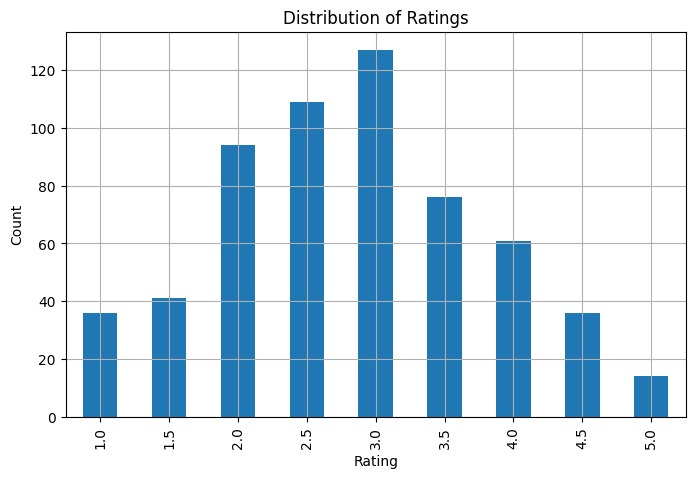

In [9]:
fig, ax = plt.subplots()
ratings['rating'].value_counts().sort_index().plot(kind='bar', ax=ax)

ax.set_title("Distribution of Ratings")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
ax.grid(True)
plt.show()

In [11]:
interactions[ ['clicked', "completed", 'minutes_watched']].describe()

,clicked,completed,minutes_watched
count,594.0,594.000000,594.000000
mean,1.0,0.186869,112.526936
std,0.0,0.390135,50.859129
min,1.0,0.000000,20.000000
25%,1.0,0.000000,76.000000
50%,1.0,0.000000,104.000000
75%,1.0,0.000000,144.000000
max,1.0,1.000000,300.000000


In [12]:
courses['subject'].value_counts()

,count
subject,
Python,3
Data Science,3
Machine Learning,3
Statistics,3
Business,3
Design,3
History,3
Languages,3


In [13]:
courses['level'].value_counts()

,count
level,
Beginner,8
Intermediate,8
Advanced,8


In [14]:
courses["course_text"] = (
    courses["subject"] + " " +
    courses["level"] + " " +
    courses["format"] + " " +
    courses["duration"]
)
courses[["course_id", "title", "course_text"]].head()

,course_id,title,course_text
0,C001,Python Foundations 1,Python Beginner Video Long
1,C002,Data Science Essentials 2,Data Science Beginner Reading Medium
2,C003,Machine Learning Studio 3,Machine Learning Beginner Project Long
3,C004,Statistics Lab 4,Statistics Beginner Video Long
4,C005,Business Workshop 5,Business Beginner Video Short


In [18]:
user_item = ratings.pivot_table(
    index = "student_id",
    columns = "course_id",
    values = "rating",

)
user_item.head()

course_id,C001,C002,C003,C004,C005,C006,C007,C008,C009,C010,C011,C012,C013,C014,C015,C016,C017,C018,C019,C020,C021,C022,C023,C024
student_id,,,,,,,,,,,,,,,,,,,,,,,,
S001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.5,4.0,2.5,NaN,NaN,NaN,NaN,2.0,3.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
S002,1.0,NaN,3.5,2.0,2.0,NaN,4.0,NaN,NaN,NaN,NaN,3.0,NaN,NaN,5.0,NaN,NaN,NaN,3.0,NaN,1.5,NaN,NaN,2.5
S003,NaN,3.5,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,3.5,NaN,2.0,NaN,NaN,NaN,NaN,NaN
S004,4.5,NaN,NaN,3.5,2.5,NaN,NaN,NaN,NaN,2.5,NaN,NaN,2.5,3.5,NaN,NaN,NaN,4.5,1.0,NaN,NaN,NaN,NaN,NaN
S005,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,1.5,NaN,2.5,NaN,NaN,NaN,NaN,4.0,2.0,NaN,NaN,NaN,NaN,NaN,1.5,NaN


In [20]:
print("Matrix Shape:", user_item.shape)
print("Sparsity (% Missing):", round(user_item.isna().sum().sum() / user_item.size * 100, 2))

Matrix Shape: (80, 24)
Sparsity (% Missing): 69.06


In [21]:
user_item_filled = user_item.fillna(0)

user_similarity = pd.DataFrame(
    cosine_similarity(user_item_filled),
    index = user_item_filled.index,
    columns = user_item_filled.index
)

user_similarity.iloc[:5, :5]


student_id,S001,S002,S003,S004,S005
student_id,,,,,
S001,1.000000,0.166285,0.202660,0.106352,0.515069
S002,0.166285,1.000000,0.494367,0.224844,0.000000
S003,0.202660,0.494367,1.000000,0.151067,0.148877
S004,0.106352,0.224844,0.151067,1.000000,0.000000
S005,0.515069,0.000000,0.148877,0.000000,1.000000


In [27]:
def get_top_similar_users(target_student, similarity_matrix, n=5):
  sims = similarity_matrix.loc[target_student].drop(target_student)
  return sims.sort_values(ascending=False).head(n)

get_top_similar_users("S001", user_similarity, n=5)

,S001
student_id,
S016,0.596934
S012,0.584793
S013,0.528699
S048,0.527097
S047,0.523394


In [29]:
def get_top_similar_users(target_student, similarity_matrix, n=5):
  sims = similarity_matrix.loc[target_student].drop(target_student)
  return sims.sort_values(ascending=False).head(n)

get_top_similar_users("S002", user_similarity, n=5)

,S002
student_id,
S049,0.770527
S017,0.689933
S042,0.613318
S072,0.605471
S070,0.585004


In [31]:
def get_top_similar_users(target_student, similarity_matrix, n=5):
  sims = similarity_matrix.loc[target_student].drop(target_student)
  return sims.sort_values(ascending=False).head(n)

get_top_similar_users("S008", user_similarity, n=5)

,S008
student_id,
S052,0.655747
S079,0.609528
S036,0.575637
S019,0.543764
S011,0.508316


In [33]:
from joblib.memory import weakref
def reocmmend_user_based(target_student, user_item_matrix, similarity_matrix, n_neighbors=5, n_recommendations=5):
  similar_users = get_top_similar_users(target_student, similarity_matrix, n_neighbors)

  neighbors_ratings = user_item_matrix.loc[similar_users.index]
  weighted_scores = neighbors_ratings.mul(similar_users, axis=0).sum(axis=0)
  similarity_sums = (neighbors_ratings.notna().mul(similar_users)).sum(axis=0)
  predicted_scores = weighted_scores / similarity_sums.replace(0, np.nan)

  already_rated = user_item_matrix.loc[target_student].dropna().index
  candidates = predicted_scores.drop(already_rated).sort_values(ascending=False)
  recs = candidates.head(n_recommendations).reset_index()
  recs.columns = ["course_id", "predicted_rating"]
  return recs.merge(courses[['course_id', 'title', 'subject', 'level']], on="course_id", how='left')

In [34]:
reocmmend_user_based("S001", user_item, user_similarity)

,course_id,predicted_rating,title,subject,level
0,C001,NaN,Python Foundations 1,Python,Beginner
1,C002,NaN,Data Science Essentials 2,Data Science,Beginner
2,C003,NaN,Machine Learning Studio 3,Machine Learning,Beginner
3,C004,NaN,Statistics Lab 4,Statistics,Beginner
4,C005,NaN,Business Workshop 5,Business,Beginner


In [35]:
reocmmend_user_based("S008", user_item, user_similarity)

,course_id,predicted_rating,title,subject,level
0,C002,NaN,Data Science Essentials 2,Data Science,Beginner
1,C003,NaN,Machine Learning Studio 3,Machine Learning,Beginner
2,C004,NaN,Statistics Lab 4,Statistics,Beginner
3,C005,NaN,Business Workshop 5,Business,Beginner
4,C006,NaN,Design Toolkit 6,Design,Beginner
